In [2]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
identify_significant_up_and_down_DEGs <- function(DEG_df) {
  num_up_DEGs <- DEG_df %>%
    dplyr::filter(significant == "True" & log2FoldChange > 0) %>%
    nrow()
  
  num_down_DEGs <- DEG_df %>%
    dplyr::filter(significant == "True" & log2FoldChange < 0) %>%
    nrow()
  
  return(c(num_up_DEGs, num_down_DEGs))
}

In [7]:
cell_types <- c("Adipocyte", "Cardiomyocyte", "Endocardial", "Endothelial", "Epicardial",
                "Fibroblast", "Lymphoid", "LEC", "Mast", "Myeloid", "Neuronal", "Pericyte", "vSMC")

dev_DEG_up_list <- c()
dev_DEG_down_list <- c()

for (cell_type in cell_types) {
  # age comparison
  cell_type_age_df <- read.csv(
    paste0("pydeseq2_results/", cell_type, "_disease_binary_Y_vs_N_results.csv"),
    row.names = 1
  )
    
  dev_counts <- identify_significant_up_and_down_DEGs(cell_type_age_df)
  
  dev_DEG_up_list <- c(dev_DEG_up_list, dev_counts[[1]])
  dev_DEG_down_list <- c(dev_DEG_down_list, dev_counts[[2]])
}

dev_deg_down_df <- data.frame(
  cell_type = cell_types,
  DEG = dev_DEG_down_list,
  direction = "down"
)

dev_deg_up_df <- data.frame(
  cell_type = cell_types,
  DEG = dev_DEG_up_list,
  direction = "up"
)

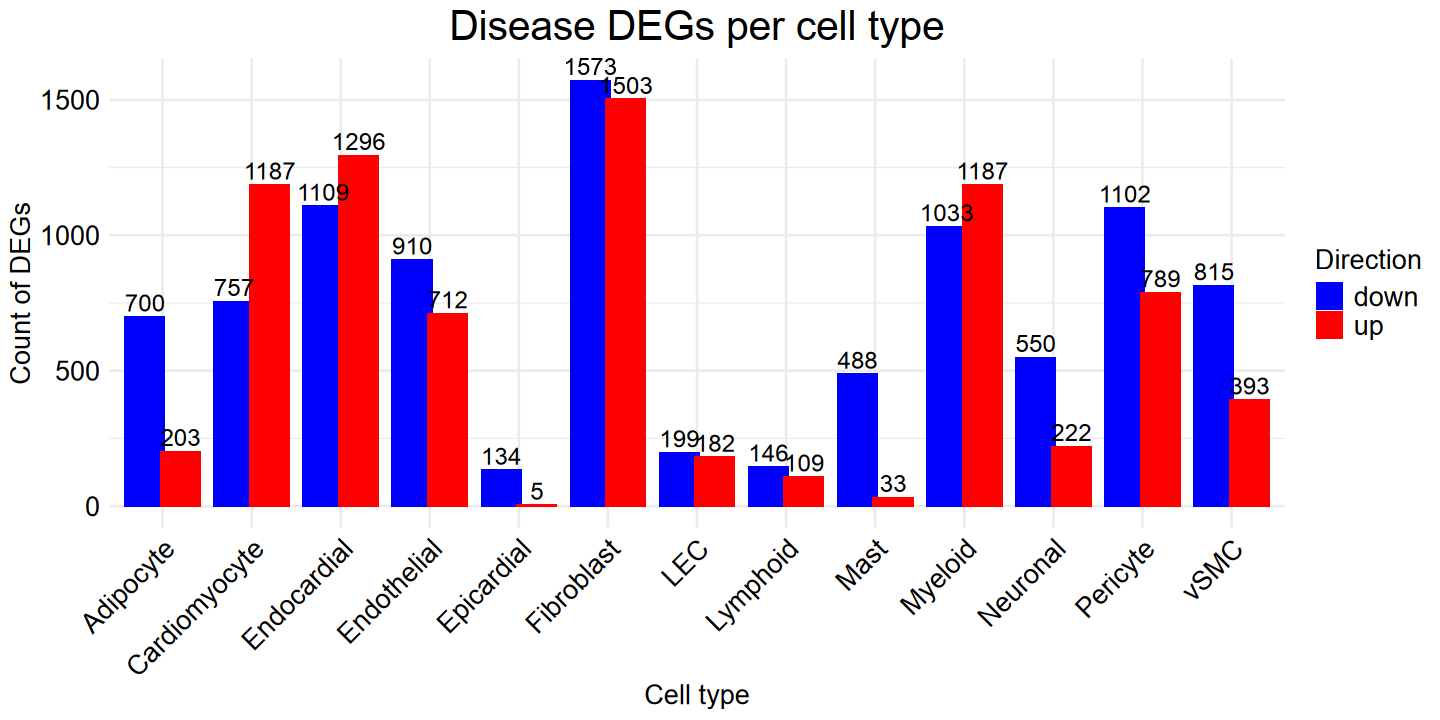

In [8]:
options(repr.plot.width = 12, repr.plot.height = 6)

# combine up and down into one dataframe
concat_age_df <- bind_rows(dev_deg_down_df, dev_deg_up_df)

# plot
p1 <- ggplot(concat_age_df, aes(x = cell_type, y = DEG, fill = direction)) +
  geom_col(position = position_dodge(width = 0.8)) +
  geom_text(aes(label = DEG),
            position = position_dodge(width = 0.8),
            vjust = -0.3, size = 5) +
  scale_fill_manual(values = c("up" = "red", "down" = "blue")) +
  labs(
    x = "Cell type",
    y = "Count of DEGs",
    title = "Disease DEGs per cell type",
    fill = "Direction"
  ) +
  theme_minimal(base_size = 12) +
  theme(legend.text = element_text(size = 16), 
         legend.title = element_text(size = 16, color = "black"), 
         plot.title = element_text(size = 24, hjust = 0.5, color = "black"), 
         axis.title.x = element_text(size = 16, color = "black"),
         axis.title.y = element_text(size = 16, color = "black"),
         axis.text.x = element_text(size = 16, angle = 45, hjust = 1, color = "black"),
         axis.text.y = element_text(size = 16, color = "black"),
	 strip.text = element_text(size = 18, color = "black"))

ggsave(p1, filename = "04_num_disease_DEG_per_cell_type.pdf", width = 12, height = 6)

p1